# MK-MMD(Multiple Kernel-Maximum Mean Discrepancy)
- 多核最大化均值差异，常用来度量两个分布之间的距离
- 通过核函数，将数据映射到一个再生希尔伯特空间中，然后计算两个分布的映射的均值在希尔伯特空间中的距离，就得到了两个分布的差异
<img src="https://pic1.zhimg.com/v2-30c6c28b7dca65ec2600e9c6ecc9aa3a_1440w.jpg" align="center">


## 生成两组不同分布数据
- 一个来自对数正态分布，一个来自beta分布

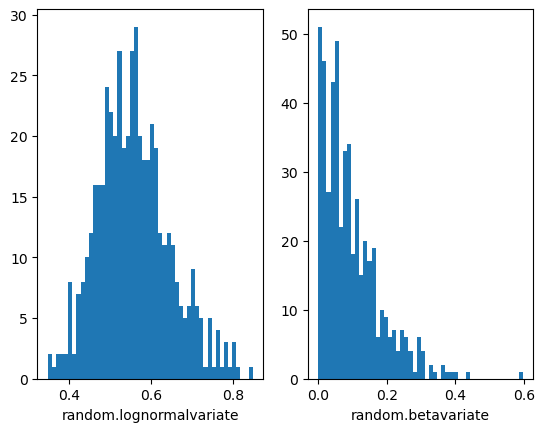

In [2]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np

SAMPLE_SIZE = 500
buckets = 50

# 第一种分布：对数正态分布，得到一个均值为mu，标准差为sigma的正态分布。mu可以取任何值，sigma必须大于零。
plt.subplot(1,2,1)
plt.xlabel("random.lognormalvariate")
mu = -0.6
sigma = 0.15 # 将输出数据限制到0-1之间
diff1=[]
for i in range(10):
    diff1.append([random.lognormvariate(mu, sigma) for _ in range(0, SAMPLE_SIZE)])
plt.hist(diff1[0], buckets)

# 第二种分布：beta分布。参数的条件是alpha 和 beta 都要大于0， 返回值在0~1之间。
plt.subplot(1,2,2)
plt.xlabel("random.betavariate")
alpha = 1
beta = 10
diff2=[]
for i in range(10):
    diff2.append([random.betavariate(alpha, beta) for _ in range(0, SAMPLE_SIZE)])
plt.hist(diff2[0], buckets)
plt.show()


- 计算方法：计算机习惯于矩阵运算，得到MK-MMD的计算机计算公式如下，部分地方用到了恒等变换
  <img src="https://pic4.zhimg.com/v2-caa11dc95653772e6d7278cd399a1a9f_1440w.jpg">

### 代码功能与数学公式对应解析

#### **核心目标**
该代码实现**最大均值差异（Maximum Mean Discrepancy, MMD）** 的计算，用于衡量两个分布（源域$\mathcal{D}_s$ 和目标域 $\mathcal{D}_t$）的相似性。MMD 基于核方法，通过比较两个分布的特征空间均值差异来量化分布差异。

### **关键步骤与公式对应**

#### 1. **高斯核矩阵构建 (`guassian_kernel` 函数)**


**数学背景**：
- 核函数 $k(\cdot, \cdot)$ 是高斯核（RBF 核），定义为：
  $$
  k(x, y) = \exp\left(-\frac{\|x - y\|^2}{2\sigma^2}\right).
  $$

**代码逻辑**：
1. **合并数据**：
   ```python
   total = torch.cat([source, target], dim=0)
   ```
   - 将源域数据 $X \in \mathbb{R}^{n \times d}$ 和目标域数据 $ Y \in \mathbb{R}^{m \times d} $ 合并为 $ Z \in \mathbb{R}^{(n + m) \times d} $。

2. **计算 L2 距离矩阵**：
   ```python
   L2_distance = ((total0 - total1)**2).sum(2)
   ```
   - 计算任意两个样本之间的欧氏距离平方，得到 $ (n + m) \times (n + m) $ 的距离矩阵。

3. **动态选择带宽（Bandwidth）**：
   ```python
   if fix_sigma:
       bandwidth = fix_sigma
   else:
       bandwidth = torch.sum(L2_distance.data) / (n_samples**2 - n_samples)
   ```
   - 若未指定固定带宽，则通过所有样本对的平均距离计算默认带宽。

4. **多尺度高斯核组合**：
   ```python
   bandwidth_list = [bandwidth * (kernel_mul**i) for i in range(kernel_num)]
   kernel_val = [torch.exp(-L2_distance / bandwidth_temp) for bandwidth_temp in bandwidth_list]
   return sum(kernel_val)
   ```
   - 使用 `kernel_num` 个不同带宽的高斯核（如 `[σ/4, σ/2, σ, 2σ, 4σ]`），并通过线性组合得到最终核矩阵 $ K $。

**对应公式**：
- 多核组合对应公式中的多尺度核技巧，最终核矩阵 $ K $ 是多个单核的叠加：
  $$
  K = \sum_{i=1}^{kernel\_num} \alpha_i k_i(\cdot, \cdot),
  $$
  其中 $ \alpha_i = 1 $（代码中各核权重相同）。

---

#### 2. **MMD 计算 (`mmd_rbf` 函数)**

```python
def mmd_rbf(source, target, kernel_mul=2.0, kernel_num=5, fix_sigma=None):
    # ... (省略部分代码)
    XX = kernels[:batch_size, :batch_size]
    YY = kernels[batch_size:, batch_size:]
    XY = kernels[:batch_size, batch_size:]
    YX = kernels[batch_size:, :batch_size]
    loss = torch.mean(XX + YY - XY - YX)
    return loss
```

**数学背景**：
MMD 的平方形式可展开为：
$$
\begin{align*}
MMD^2[F, X, Y] &= \left\|\frac{1}{n}\sum_{i=1}^n f(x_i) - \frac{1}{m}\sum_{j=1}^m f(y_j)\right\|_\mathcal{H}^2 \\
&= \frac{1}{n^2}\sum_{i,i'=1}^n k(x_i, x_{i'}) - \frac{2}{nm}\sum_{i,j=1}^{n,m} k(x_i, y_j) + \frac{1}{m^2}\sum_{j,j'=1}^m k(y_j, y_{j'}).
\end{align*}
$$

**代码逻辑**：
1. **分割核矩阵**：
   ```python
   XX = kernels[:batch_size, :batch_size]  # 源域内核矩阵 K_{s,s}
   YY = kernels[batch_size:, batch_size:]  # 目标域内核矩阵 K_{t,t}
   XY = kernels[:batch_size, batch_size:]  # 源→目标交叉项 K_{s,t}
   YX = kernels[batch_size:, :batch_size]  # 目标→源交叉项 K_{t,s}
   ```
   - 这里假设源域和目标域的样本数相同（`batch_size = n = m`），因此 `XX` 和 `YY` 的维度均为 $ n \times n $，`XY` 和 `YX` 为 $ n \times n $。

2. **计算 MMD 损失**：
   ```python
   loss = torch.mean(XX + YY - XY - YX)
   ```
   - 对应公式中的三项：
     - $ \frac{1}{n^2} \text{Tr}(K_{s,s}) $ → `torch.mean(XX)`
     - $ \frac{1}{m^2} \text{Tr}(K_{t,t}) $ → `torch.mean(YY)`
     - $ -\frac{2}{nm} \text{Tr}(K_{s,t}) $ → `- torch.mean(XY)`（由于 `n = m`，系数简化为 `-2/n^2`）

**对应公式**：
- 代码中的 `loss` 等价于公式中的 MMD 平方形式：
  $$
  \text{loss} = \frac{1}{n^2} \text{Tr}(K_{s,s}) + \frac{1}{n^2} \text{Tr}(K_{t,t}) - \frac{2}{n^2} \text{Tr}(K_{s,t}).
  $$
  （注意：若 `n ≠ m`，则需调整系数，但代码假设 `n = m`）

---

### **变量与符号对应表**

| 代码变量                | 公式符号                     | 描述                                                                 |
|-------------------------|--------------------------|----------------------------------------------------------------------|
| `source`, `target`      | $ X $, $ Y $             | 源域和目标域的样本数据                                               |
| `kernels`               | $ K $                    | 总核矩阵（包含源域、目标域及交叉项）                                 |
| `XX`, `YY`              | $ K_{s,s} $, $ K_{t,t} $ | 源域和目标域的自相关核矩阵                                           |
| `XY`, `YX`              | $ K_{s,t} $, $ K_{t,s} $ | 源域与目标域的交叉核矩阵（对称，故 \( K_{s,t} = K_{t,s}^\top \))      |
| `loss`                  | $ MMD^2 $                | 最终的 MMD 损失值，对应公式中的平方形式                               |


### **关键假设与限制**

1. **样本数相等**：
   - 代码假设源域和目标域的样本数相同（`n = m`），因此 `batch_size = n = m`。若实际中 `n ≠ m`，需调整系数（例如替换 `1/n²` 为 `1/(n(n-1))`）。

2. **多核技巧**：
   - 通过组合多个不同带宽的高斯核（`kernel_num=5`），增强模型对不同尺度差异的敏感性。

3. **无偏估计**：
   - 代码中的 `torch.mean` 实际计算的是核矩阵的平均值，而非严格意义上的无偏估计（需减去对角线项）。但在实践中，这种简化常被接受以减少计算复杂度。

In [ ]:
import torch

def guassian_kernel(source, target, kernel_mul=2.0, kernel_num=5, fix_sigma=None):
    '''
    将源域数据和目标域数据转化为核矩阵，即上文中的K
    Params:
	    source: 源域数据（batch_size , d_model)
	    target: 目标域数据（batch_size , d_model)
	    kernel_mul:
	    kernel_num: 使用多少个高斯核
	    fix_sigma: 不同高斯核的sigma值
	Return:
		sum(kernel_val): 多个核矩阵之和
    '''
    n_samples = int(source.size()[0]) + int(target.size()[0]) # 求矩阵的行数，一般source和target的尺度是一样的，这样便于计算
    total = torch.cat([source, target], dim=0) # 将source,target按列方向合并[2*batch_size, d_model]
    # 将total复制（n+m）份 [1, 2*batch_size, d_model] -> [2*batch_size, 2*batch_size, d_model]
    total0 = total.unsqueeze(0).expand(int(total.size(0)), int(total.size(0)), int(total.size(1)))
    #将total的每一行都复制成（n+m）行，即每个数据都扩展成（n+m）份
    total1 = total.unsqueeze(1).expand(int(total.size(0)), int(total.size(0)), int(total.size(1)))
    #求任意两个数据之间的和，得到的矩阵中坐标（i,j）代表total中第i行数据和第j行数据之间的l2 distance(i==j时为0）
    L2_distance = ((total0-total1)**2).sum(2)
    #调整高斯核函数的sigma值
    if fix_sigma:
        bandwidth = fix_sigma
    else:
        bandwidth = torch.sum(L2_distance.data) / (n_samples**2-n_samples)
    #以fix_sigma为中值，以kernel_mul为倍数取kernel_num个bandwidth值（比如fix_sigma为1时，得到[0.25,0.5,1,2,4]
    bandwidth /= kernel_mul ** (kernel_num // 2)
    bandwidth_list = [bandwidth * (kernel_mul**i) for i in range(kernel_num)]
    #高斯核函数的数学表达式
    kernel_val = [torch.exp(-L2_distance / bandwidth_temp) for bandwidth_temp in bandwidth_list]
    #得到最终的核矩阵
    return sum(kernel_val) # /len(kernel_val)

def mmd_rbf(source, target, kernel_mul=2.0, kernel_num=5, fix_sigma=None):
    '''
    计算源域数据和目标域数据的MMD距离
    Params:
	    source: 源域数据（n * len(x))
	    target: 目标域数据（m * len(y))
	    kernel_mul:
	    kernel_num: 取不同高斯核的数量
	    fix_sigma: 不同高斯核的sigma值
	Return:
		loss: MMD loss
    '''
    batch_size = int(source.size()[0]) # 一般默认为源域和目标域的batchsize相同
    kernels = guassian_kernel(source, target,
        kernel_mul=kernel_mul, kernel_num=kernel_num, fix_sigma=fix_sigma)
    #根据式（3）将核矩阵分成4部分
    XX = kernels[:batch_size, :batch_size]
    YY = kernels[batch_size:, batch_size:]
    XY = kernels[:batch_size, batch_size:]
    YX = kernels[batch_size:, :batch_size]
    loss = torch.mean(XX + YY - XY -YX)
    return loss # 因为一般都是n==m，也就是batch_size，所以L矩阵一般不加入计算

In [20]:
import torch

batch_size = 1
d_model = 2
source = torch.arange(0, 2,  dtype=torch.float32).unsqueeze(0)
target = torch.arange(2, 4, dtype=torch.float32).unsqueeze(0)
source, target.shape

(tensor([[0., 1.]]), torch.Size([1, 2]))

In [21]:
total = torch.cat([source, target], dim=0)
total, total.shape

(tensor([[0., 1.],
         [2., 3.]]),
 torch.Size([2, 2]))

In [22]:
total0 = total.unsqueeze(0).expand(total.shape[0], total.shape[0], total.shape[1])
total0, total0.shape

(tensor([[[0., 1.],
          [2., 3.]],
 
         [[0., 1.],
          [2., 3.]]]),
 torch.Size([2, 2, 2]))

In [24]:
total1 = total.unsqueeze(1).expand(total.shape[0], total.shape[0], total.shape[1])
total1

tensor([[[0., 1.],
         [0., 1.]],

        [[2., 3.],
         [2., 3.]]])

In [27]:
((total1 - total0) ** 2).sum(2)

tensor([[0., 8.],
        [8., 0.]])

In [10]:
((total1 - total1) ** 2).sum(2).shape

torch.Size([4, 4])

In [31]:
from PIL import Image
from torchvision import transforms as T
import os

image_path_root = "my_data/images/"
img_list = os.listdir(image_path_root)
len(img_list)

5104

In [47]:
img_tensor = T.ToTensor()(Image.open(os.path.join(image_path_root, img_list[random.randint(0, len(img_list))])))
img_tensor.shape, T.ToPILImage()(img_tensor).show()

(torch.Size([1, 2147, 3692]), None)

In [50]:
img_tensor.min()

tensor(0.)

In [56]:
import numpy as np
image_path = "./my_data/images/000_152351670.jpg"
img = Image.open(image_path)
img_np = np.array(img)
img_tensor = torch.from_numpy(img_np).unsqueeze(0)

In [57]:
img_tensor.shape

torch.Size([1, 2147, 3692])

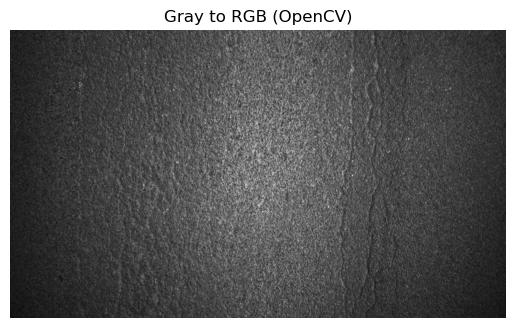

In [58]:
import cv2
import matplotlib.pyplot as plt

# 读取灰度图（注意：OpenCV 默认读取为 BGR 格式）
gray_image = cv2.imread("./my_data/images/000_092524079.jpg", 0)  # 0 表示以灰度模式读取

# 将灰度图转换为 RGB 图像（复制三通道）
rgb_image = cv2.cvtColor(gray_image, cv2.COLOR_GRAY2RGB)

# 使用 Matplotlib 展示图像
plt.imshow(rgb_image)
plt.title("Gray to RGB (OpenCV)")
plt.axis("off")
plt.show()

In [59]:
rgb_image.shape

(2147, 3692, 3)

In [60]:
image_path = 'my_data/rgb_images/000_092524079.jpg'
img = Image.open(image_path)
img_tensor = T.ToTensor()(img)
img_tensor.shape

torch.Size([3, 2147, 3692])